# AWS Comprehend Sentiment Analysis

In [2]:
import pandas as pd
import boto3
import time
import matplotlib.pyplot as plt

print("🧠 Initializing AWS Comprehend client...")

comprehend = boto3.client(
    "comprehend",
    region_name="eu-west-1"
)

print("✅ AWS Comprehend client ready")


🧠 Initializing AWS Comprehend client...
✅ AWS Comprehend client ready


#### Load translated dataset

In [3]:
print("📄 Loading translated articles...")

df = pd.read_csv("articles.csv")

print("✅ Dataset loaded")
print("Columns:", list(df.columns))
print("Total rows:", len(df))


📄 Loading translated articles...
✅ Dataset loaded
Columns: ['source', 'language', 'url', 'article_text', 'text_orig_ln', 'translated_text', 'translate_error', 'sentiment', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'sentiment_mixed']
Total rows: 30


#### Sentiment Columns

In [4]:
sentiment_cols = [
    "sentiment",
    "sentiment_positive",
    "sentiment_negative",
    "sentiment_neutral",
    "sentiment_mixed"
]

for col in sentiment_cols:
    if col not in df.columns:
        df[col] = pd.NA


In [5]:
print("🔍 Running sentiment analysis with AWS Comprehend...")

for idx, row in df[df["translated_text"].notna()].iterrows():
    try:
        response = comprehend.detect_sentiment(
            Text=str(row["translated_text"])[:5000],  # AWS limit
            LanguageCode="en"
        )

        df.at[idx, "sentiment"] = response["Sentiment"]
        df.at[idx, "sentiment_positive"] = response["SentimentScore"]["Positive"]
        df.at[idx, "sentiment_negative"] = response["SentimentScore"]["Negative"]
        df.at[idx, "sentiment_neutral"] = response["SentimentScore"]["Neutral"]
        df.at[idx, "sentiment_mixed"] = response["SentimentScore"]["Mixed"]

        print(f"✅ Analyzed row {idx}")

        time.sleep(0.1)

    except Exception as e:
        print(f"❌ Sentiment failed at row {idx}: {str(e)}")


🔍 Running sentiment analysis with AWS Comprehend...
❌ Sentiment failed at row 0: An error occurred (TextSizeLimitExceededException) when calling the DetectSentiment operation: Input text size exceeds limit. Max length of request text allowed is 5000 bytes while in this request the text size is 5003 bytes
✅ Analyzed row 1
❌ Sentiment failed at row 2: An error occurred (TextSizeLimitExceededException) when calling the DetectSentiment operation: Input text size exceeds limit. Max length of request text allowed is 5000 bytes while in this request the text size is 5002 bytes
✅ Analyzed row 3
✅ Analyzed row 4
✅ Analyzed row 5
✅ Analyzed row 6
❌ Sentiment failed at row 7: An error occurred (TextSizeLimitExceededException) when calling the DetectSentiment operation: Input text size exceeds limit. Max length of request text allowed is 5000 bytes while in this request the text size is 5012 bytes
✅ Analyzed row 8
✅ Analyzed row 9
✅ Analyzed row 10
✅ Analyzed row 11
✅ Analyzed row 12
❌ Sentiment f

In [6]:
df.to_csv("articles.csv", index=False)

print("💾 Sentiment results saved")


💾 Sentiment results saved


### Table 1 — Sentiment distribution

In [7]:
sentiment_counts = df["sentiment"].value_counts()

sentiment_counts


sentiment
NEUTRAL    16
MIXED       2
Name: count, dtype: int64

### Chart 1 — Overall sentiment distribution

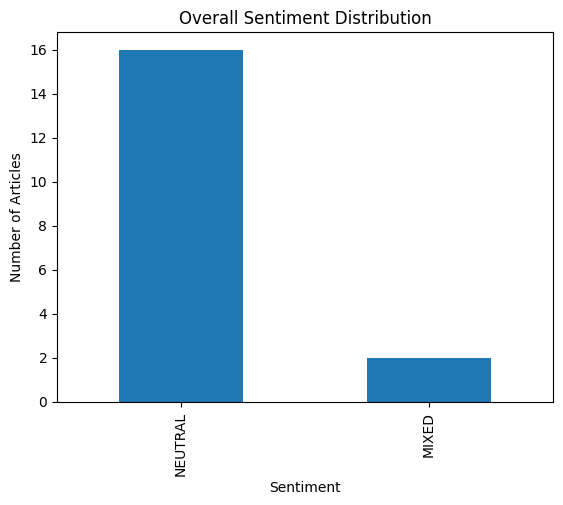

In [8]:
sentiment_counts.plot(kind="bar")
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Articles")
plt.show()


### Table 2 — Sentiment by source

In [9]:
sentiment_by_source = (
    df.groupby(["source", "sentiment"])
      .size()
      .unstack(fill_value=0)
)

sentiment_by_source


sentiment,MIXED,NEUTRAL
source,,
Prothom Alo,0,11
The Daily Star,2,5


### Chart 2 — Sentiment comparison by source

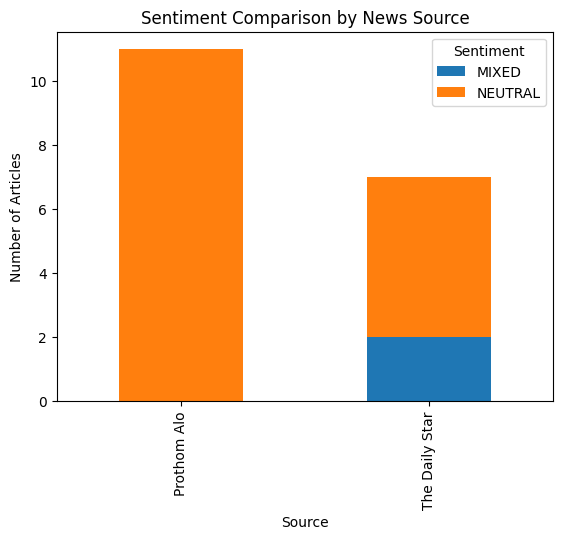

In [10]:
sentiment_by_source.plot(kind="bar", stacked=True)
plt.title("Sentiment Comparison by News Source")
plt.xlabel("Source")
plt.ylabel("Number of Articles")
plt.legend(title="Sentiment")
plt.show()


### Chart 3 — Average sentiment scores by source

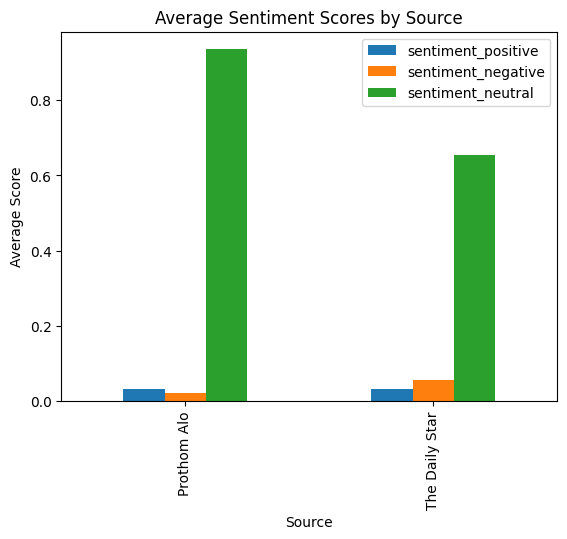

In [11]:
avg_scores = df.groupby("source")[
    ["sentiment_positive", "sentiment_negative", "sentiment_neutral"]
].mean()

avg_scores.plot(kind="bar")
plt.title("Average Sentiment Scores by Source")
plt.xlabel("Source")
plt.ylabel("Average Score")
plt.show()
